## Prova singola su un solo modello [obsoleta]

### Funzione di supporto preliminare [obsoleta]

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import keras
import cv2
import os

# 1. Carica il modello
#model_path = r"C:\GitHub\ProgettoDL_FaceFERward\experiments\20260627_180349_cnn_v1\model.keras"
model_path = r"C:\GitHub\ProgettoDL_FaceFERward\experiments\20260627_180349_cnn_v1\model.keras"
model = keras.models.load_model(model_path)

# Costruiamo un modello funzionale ad hoc per estrarre le attivazioni.
# Poiché il modello Sequential è una lista sequenziale di layer, possiamo 
# ricreare il flusso passando l'input attraverso i vari strati fino a quello che ci interessa.

# Definiamo l'input formale basandoci sulla forma accettata dal tuo modello (48x48x1)
input_tensor = keras.Input(shape=(48, 48, 1))

# Variabili in cui salveremo l'output del conv layer e l'output finale
x = input_tensor
conv_output_tensor = None

last_conv_layer_name = "conv2d_9"

# Iteriamo attraverso tutti i layer del modello sequenziale
for layer in model.layers:
    x = layer(x)
    if layer.name == last_conv_layer_name:
        conv_output_tensor = x

# Creiamo il grad_model usando l'API Funzionale, ora che i tensori sono connessi correttamente
grad_model = keras.models.Model(
    inputs=input_tensor,
    outputs=[conv_output_tensor, x]
)

def compute_gradcam(img_array, class_index=None):
    # Assicurati che img_array sia (1, 48, 48, 1)
    if len(img_array.shape) == 3:
        img_array = np.expand_dims(img_array, axis=0)
        
    # Usiamo il backend di Keras 3 per il GradientTape
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = np.argmax(predictions[0])
        
        loss = predictions[:, class_index]

    # Gradienti dell'output rispetto alle mappe di attivazione
    grads = tape.gradient(loss, conv_outputs)

    # Global Average Pooling dei gradienti
    pooled_grads = np.mean(grads, axis=(0, 1, 2))

    # Ponderazione delle mappe di attivazione
    conv_outputs = conv_outputs[0].numpy() if hasattr(conv_outputs, "numpy") else conv_outputs[0]
    cam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)
    
    for i, w in enumerate(pooled_grads):
        cam += w * conv_outputs[:, :, i]

    # Applichiamo la ReLU
    cam = np.maximum(cam, 0)
    
    # Normalizzazione
    if np.max(cam) != 0:
        cam = cam / np.max(cam)
        
    return cam

# --- Esempio di test con dati casuali ---
# Sostituisci questo array con un'immagine reale del tuo dataset normalizzata (es. divisa per 255)
#test_image = np.random.rand(1, 48, 48, 1).astype(np.float32)

#heatmap = compute_gradcam(test_image)

# Mostra la heatmap
#heatmap_resized = cv2.resize(heatmap, (48, 48))
#heatmap_color = np.uint8(255 * heatmap_resized)
#heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)

#plt.imshow(heatmap_color)
#plt.title("Grad-CAM Superata!")
#plt.axis("off")
#plt.show()

-> Originale trovata in:  \train\happy\Training_11204.jpg
-> Processata trovata in: \validation\happy\Training_11204.jpg


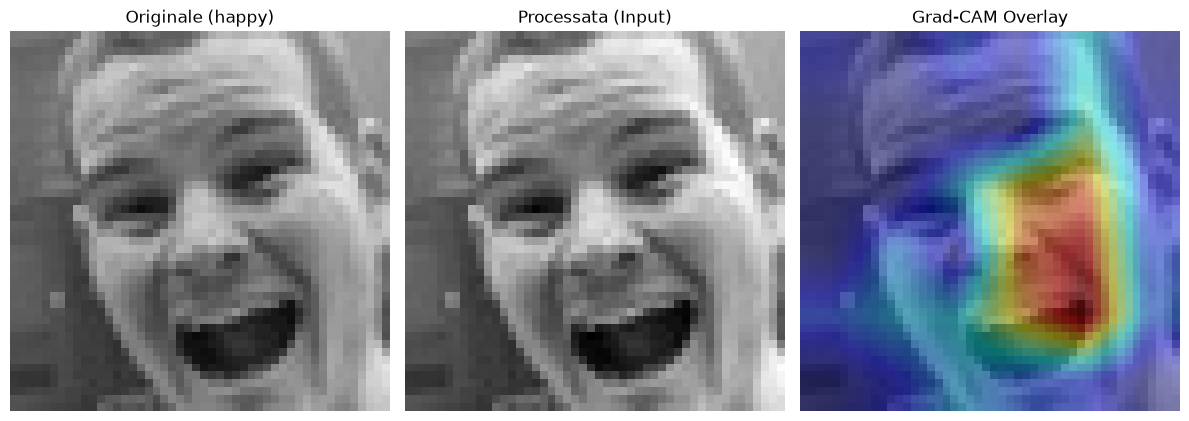

In [16]:
# --- CONFIGURAZIONE PERCORSI BASE ---
PATH_ORIGINAL_BASE = r"C:\GitHub\ProgettoDL_FaceFERward\data\original"
PATH_PROCESSED_BASE = r"C:\GitHub\ProgettoDL_FaceFERward\data\processed"

def trova_path_file(percorso_base, nome_classe, nome_file):
    """
    Cerca ricorsivamente un file data la sua classe e il suo nome 
    all'interno delle sotto-cartelle (train, test, validation).
    """
    for root, dirs, files in os.walk(percorso_base):
        # Controlliamo che siamo nella cartella della classe corretta (es. .../happy)
        if os.path.basename(root) == nome_classe:
            if nome_file in files:
                return os.path.join(root, nome_file)
    return None

# --- CHIAVI DI RICERCA ---
NOME_CLASSE = "happy" # Sostituisci con la tua classe
NOME_FILE = "Training_11204.jpg" # Sostituisci con il nome del file che vuoi analizzare

# Ricerca automatica dei percorsi reali
path_originale = trova_path_file(PATH_ORIGINAL_BASE, NOME_CLASSE, NOME_FILE)
path_processata = trova_path_file(PATH_PROCESSED_BASE, NOME_CLASSE, NOME_FILE)

# --- VERIFICA E COERENZA ---
if path_originale and path_processata:
    print(f"-> Originale trovata in:  {path_originale.replace(PATH_ORIGINAL_BASE, '')}")
    print(f"-> Processata trovata in: {path_processata.replace(PATH_PROCESSED_BASE, '')}")
    
    # 1. Carica l'immagine originale per l'overlay finale
    img_originale = cv2.imread(path_originale)
    img_originale_rgb = cv2.cvtColor(img_originale, cv2.COLOR_BGR2RGB)
    
    # 2. Carica l'immagine processata per il modello
    img_proc = cv2.imread(path_processata, cv2.IMREAD_GRAYSCALE)
    
    # Prepara l'input per la rete (normalizzazione + dimensioni di batch/canale)
    img_proc_input = img_proc.astype("float32") / 255.0
    img_proc_input = np.expand_dims(np.expand_dims(img_proc_input, axis=-1), axis=0)
    
    # 3. Calcola la Grad-CAM
    heatmap = compute_gradcam(img_proc_input)
    
    # 4. Ridimensiona la heatmap sulle dimensioni dell'immagine ORIGINALE
    altezza_orig, larghezza_orig = img_originale_rgb.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (larghezza_orig, altezza_orig))
    
    # Crea l'overlay colorato
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(img_originale_rgb, 0.6, heatmap_color, 0.4, 0)
    
    # 5. Visualizzazione dei risultati
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_originale_rgb)
    plt.title(f"Originale ({NOME_CLASSE})")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_proc, cmap="gray")
    plt.title("Processata (Input)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

else:
    print(" Errore: Non è stato possibile trovare il file in entrambi i rami.")
    if not path_originale:   print(f" -> Manca nei dati 'originali' per la classe {NOME_CLASSE}")
    if not path_processata:  print(f" -> Manca nei dati 'processati' per la classe {NOME_CLASSE}")

## Funzione che cicla su tutti i modelli già salvati

Utilizza l'ispezione dinamica per capire la topologia del modello, estrae la porzione corretta tramite le API funzionali di Keras, elabora l'input in modo dinamico e cicla su tutti i tuoi esperimenti

### Inizializzazione path e funzioni di supporto

In [46]:
import os
import cv2
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE PERCORSI ---
PATH_EXPERIMENTS = r"C:\GitHub\ProgettoDL_FaceFERward\experiments"
PATH_ORIGINALI_BASE = r"C:\GitHub\ProgettoDL_FaceFERward\data\original"
PATH_PROCESSATE_BASE = r"C:\GitHub\ProgettoDL_FaceFERward\data\processed"
PATH_OUTPUT_PLOT = r"C:\GitHub\ProgettoDL_FaceFERward\gradcam_results"

os.makedirs(PATH_OUTPUT_PLOT, exist_ok=True)

# --- CHIAVI DI RICERCA PER L'IMMAGINE DA USARE ---
CLASSI = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NOME_CLASSE = "happy"
NOME_FILE = "Training_11204.jpg"

# --- 1. RICERCA E CARICAMENTO DELLE IMMAGINI ---
def trova_percorso_file(percorso_base, nome_classe, nome_file):
    for root, dirs, files in os.walk(percorso_base):
        if os.path.basename(root) == nome_classe and nome_file in files:
            return os.path.join(root, nome_file)
    return None

path_originale = trova_percorso_file(PATH_ORIGINALI_BASE, NOME_CLASSE, NOME_FILE)
path_processata = trova_percorso_file(PATH_PROCESSATE_BASE, NOME_CLASSE, NOME_FILE)

if not path_originale or not path_processata:
    raise FileNotFoundError("Impossibile trovare l'immagine specificata in uno dei due rami.")

# Caricamento e preparazione delle immagini base
img_originale = cv2.imread(path_originale)
img_originale_rgb = cv2.cvtColor(img_originale, cv2.COLOR_BGR2RGB)
altezza_orig, larghezza_orig = img_originale_rgb.shape[:2]

img_proc = cv2.imread(path_processata, cv2.IMREAD_GRAYSCALE)
img_proc_input = img_proc.astype("float32") / 255.0
img_proc_input = np.expand_dims(np.expand_dims(img_proc_input, axis=-1), axis=0)


# --- 2. FUNZIONE GRAD-CAM UNIVERSALE (INTEGRAZIONE NATIVA TAPE) ---
def get_gradcam_heatmap(img_tensor, model, target_layer_name, is_nested, nested_layer):
    """
    Genera la heatmap Grad-CAM in modo nativo estraendo i sotto-componenti del grafo.
    Risolve il problema dei modelli Sequential usando un approccio di forward pass esplicito
    sotto GradientTape quando necessario.
    """
    # Identifichiamo i layer di classificazione custom aggiunti in coda al modello principale
    gap_layer, dropout_layer, dense_layer = None, None, None
    
    for layer in model.layers:
        if "global_average_pooling2d" in layer.name or "global_pooling" in layer.name:
            gap_layer = layer
        elif "dropout" in layer.name:
            dropout_layer = layer
        elif "dense" in layer.name:
            dense_layer = layer

    # CASO A: Il modello ha una struttura annidata (es. MobileNetV2 Transfer Learning)
    if is_nested:
        base_grad_model = tf.keras.models.Model(
            nested_layer.inputs, 
            nested_layer.get_layer(target_layer_name).output
        )
        
        with tf.GradientTape() as tape:
            last_conv_layer_output = base_grad_model(img_tensor)
            x = last_conv_layer_output
            if gap_layer and dropout_layer and dense_layer:
                x = gap_layer(x)
                x = dropout_layer(x, training=False)
                preds = dense_layer(x)
            else:
                preds = model(img_tensor)
                
            class_index = tf.argmax(preds[0])
            class_channel = preds[:, class_index]
            
    # CASO B: Il modello è una CNN flat/sequenziale costruita da zero
    else:
        # Se il modello è un Sequential puro (o contiene un blocco Sequential non inizializzato),
        # l'estrazione funzionale standard fallisce. Ricostruiamo il flusso layer per layer sotto il Tape.
        with tf.GradientTape() as tape:
            x = img_tensor
            last_conv_layer_output = None
            
            # Scorriamo i layer uno alla volta calcolando gli output dinamici
            for layer in model.layers:
                # Gestione dei layer di BatchNormalization o Dropout se presenti nelle tue CNN
                if isinstance(layer, (keras.layers.BatchNormalization, keras.layers.Dropout)):
                    x = layer(x, training=False)
                else:
                    x = layer(x)
                
                # Intercettiamo lo strato target
                if layer.name == target_layer_name:
                    last_conv_layer_output = x
            
            preds = x
            class_index = tf.argmax(preds[0])
            class_channel = preds[:, class_index]
            
        if last_conv_layer_output is None:
            raise ValueError(f"Impossibile intercettare l'output del layer: {target_layer_name}")

    # Calcolo dei gradienti comune a entrambi i rami
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizzazione ReLU nativa
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), class_index.numpy()

### Cicla su tutti i modelli salvati


[ELABORAZIONE] Elaboro il modello: 20260627_180349_cnn_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_9' (Nidificato: False)


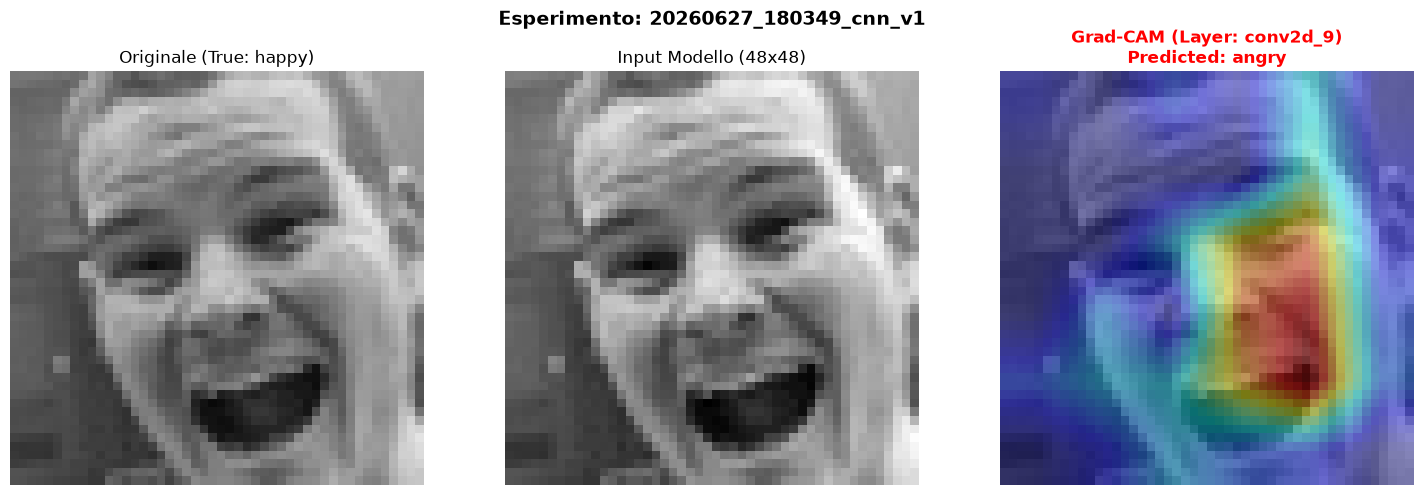


[ELABORAZIONE] Elaboro il modello: 20260628_120337_cnn_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_3' (Nidificato: False)


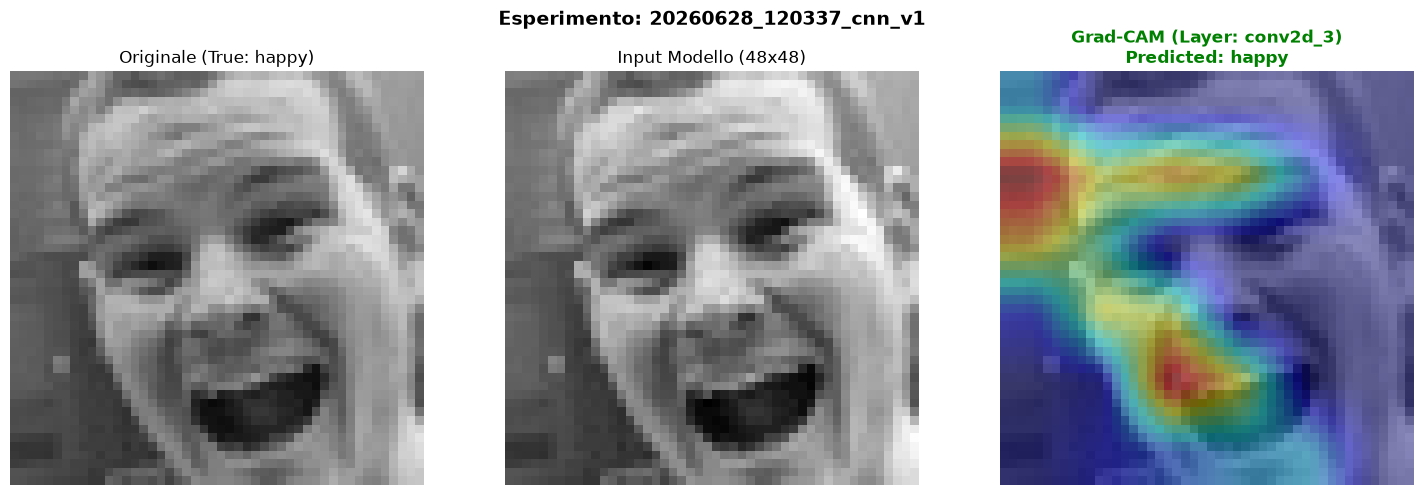


[ELABORAZIONE] Elaboro il modello: 20260628_124858_mobilenetv2_transfer
 -> Layer selezionato per Grad-CAM: 'out_relu' (Nidificato: True)


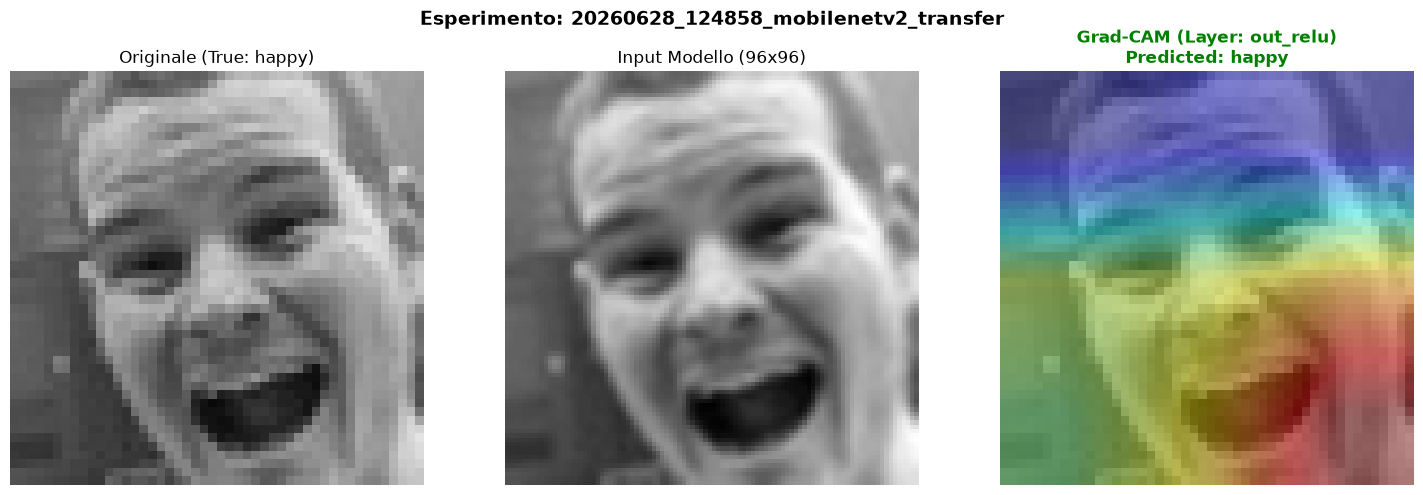


[ELABORAZIONE] Elaboro il modello: 20260628_181653_mobilenetv2_transfer
 -> Layer selezionato per Grad-CAM: 'out_relu' (Nidificato: True)


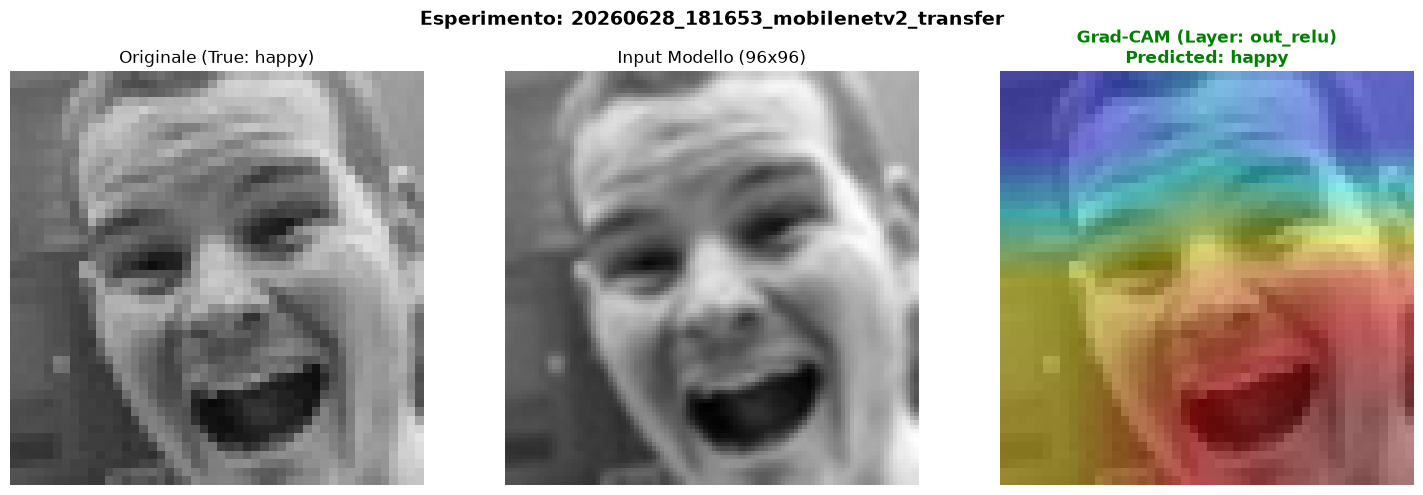


[ELABORAZIONE] Elaboro il modello: 20260629_095652_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_11' (Nidificato: False)


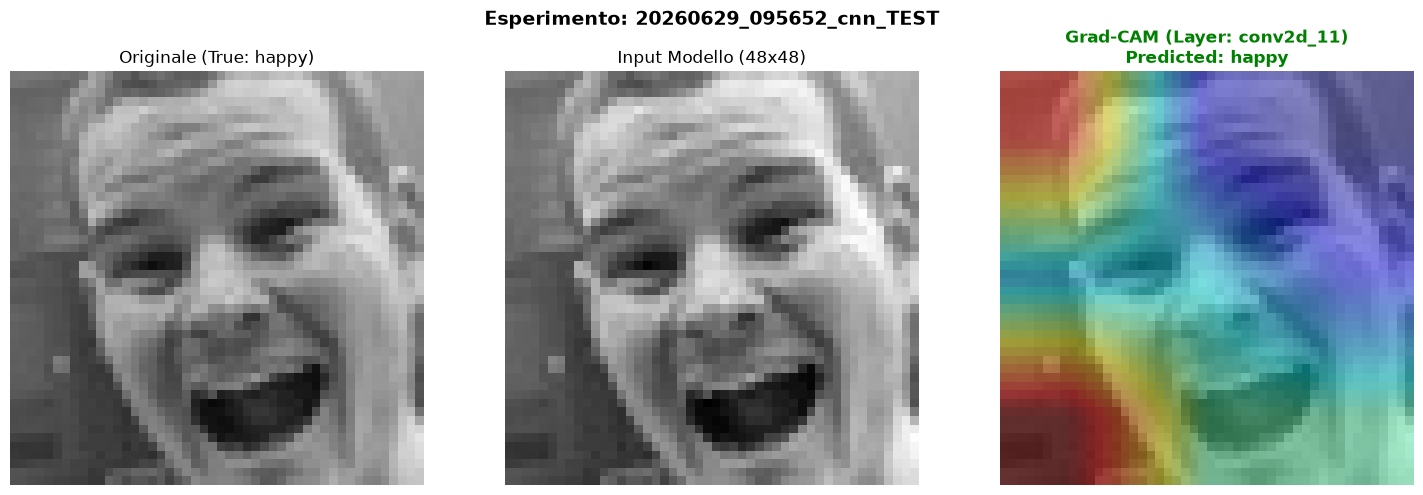


[ELABORAZIONE] Elaboro il modello: 20260629_102412_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_21' (Nidificato: False)


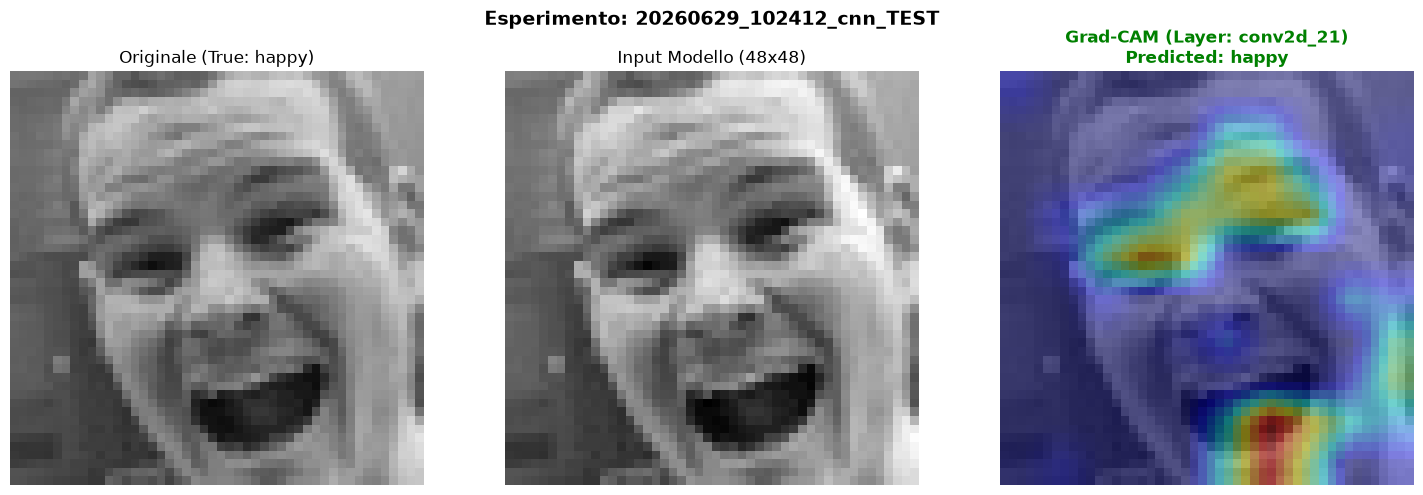


[ELABORAZIONE] Elaboro il modello: 20260629_111221_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_24' (Nidificato: False)


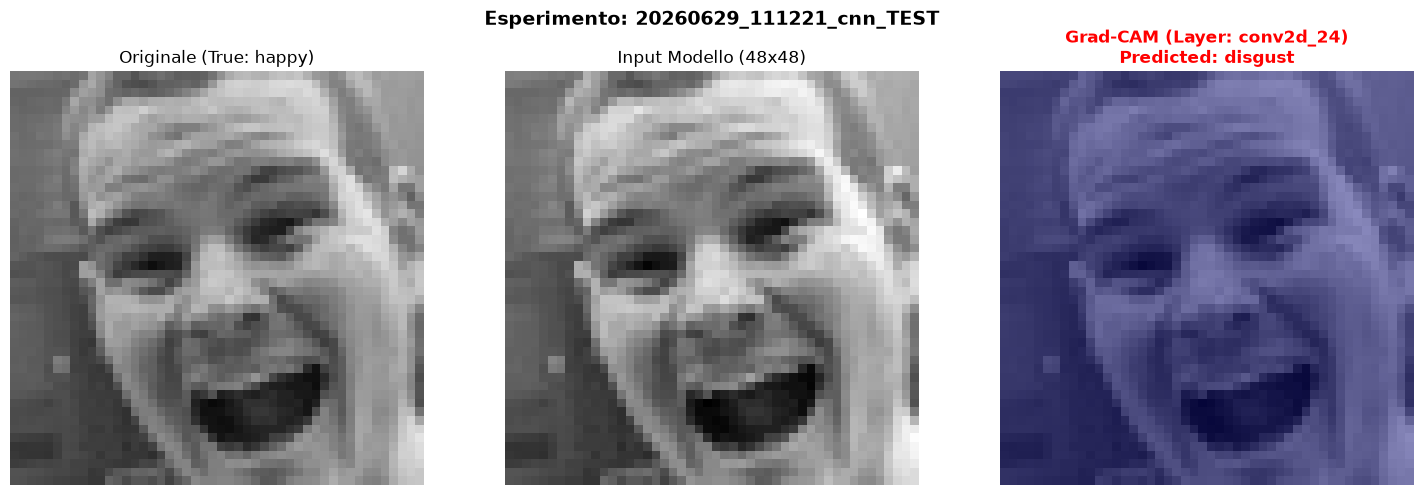


[ELABORAZIONE] Elaboro il modello: 20260629_111927_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_27' (Nidificato: False)


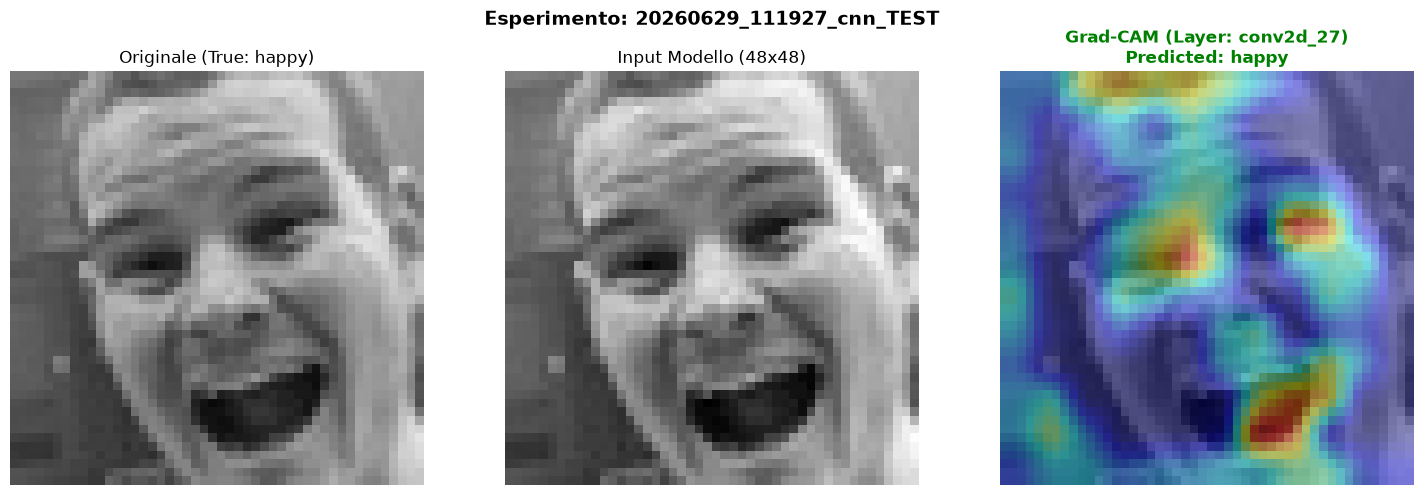


[ELABORAZIONE] Elaboro il modello: 20260629_115836_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_36' (Nidificato: False)


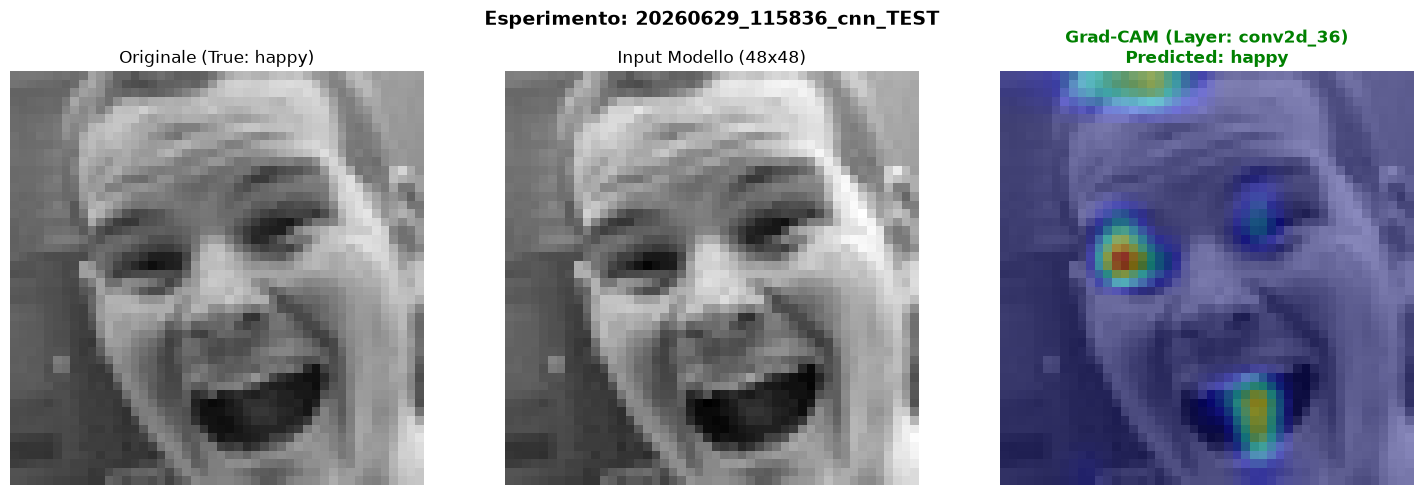


[ELABORAZIONE] Elaboro il modello: 20260629_154037_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_2' (Nidificato: False)


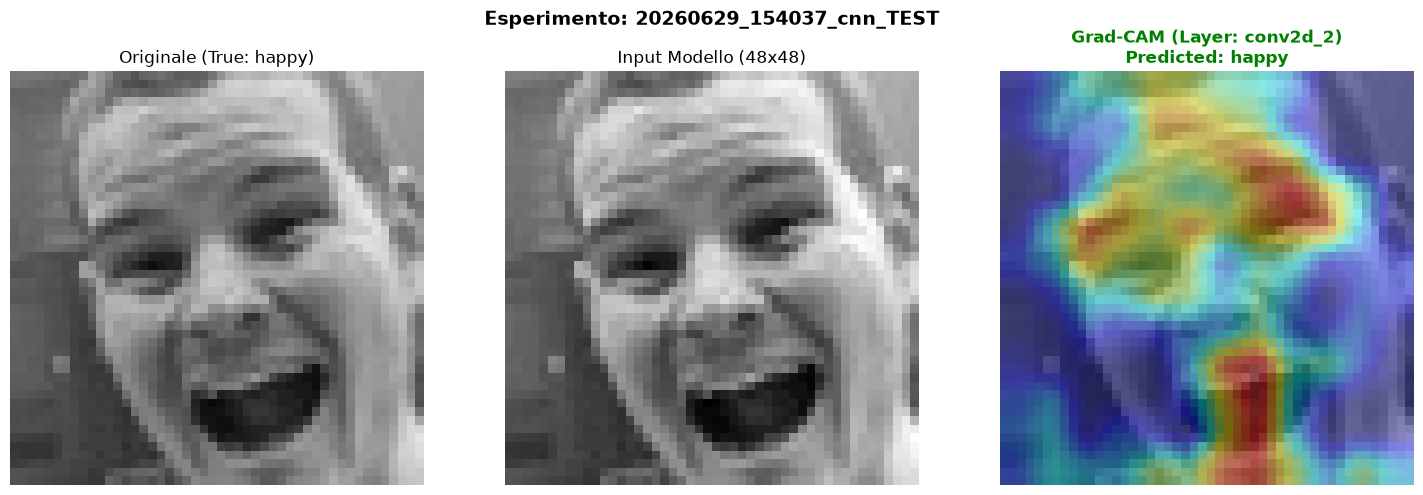


[ELABORAZIONE] Elaboro il modello: 20260629_162808_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_5' (Nidificato: False)


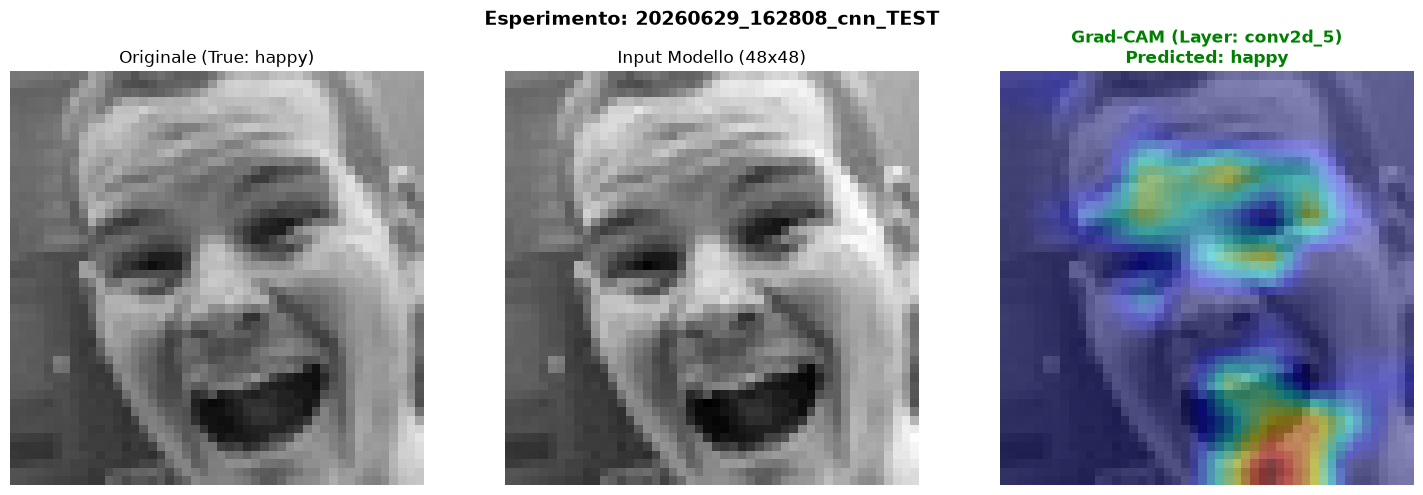


[ELABORAZIONE] Elaboro il modello: 20260629_170920_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_11' (Nidificato: False)


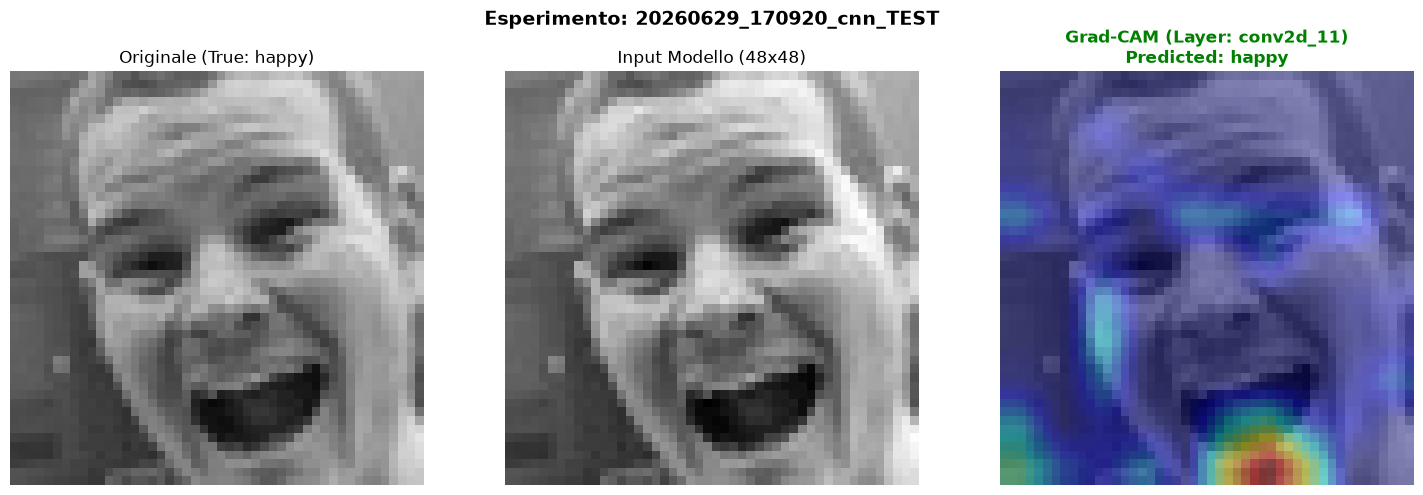


[ELABORAZIONE] Elaboro il modello: 20260629_175727_cnn_TEST
 -> Layer selezionato per Grad-CAM: 'conv2d_2' (Nidificato: False)


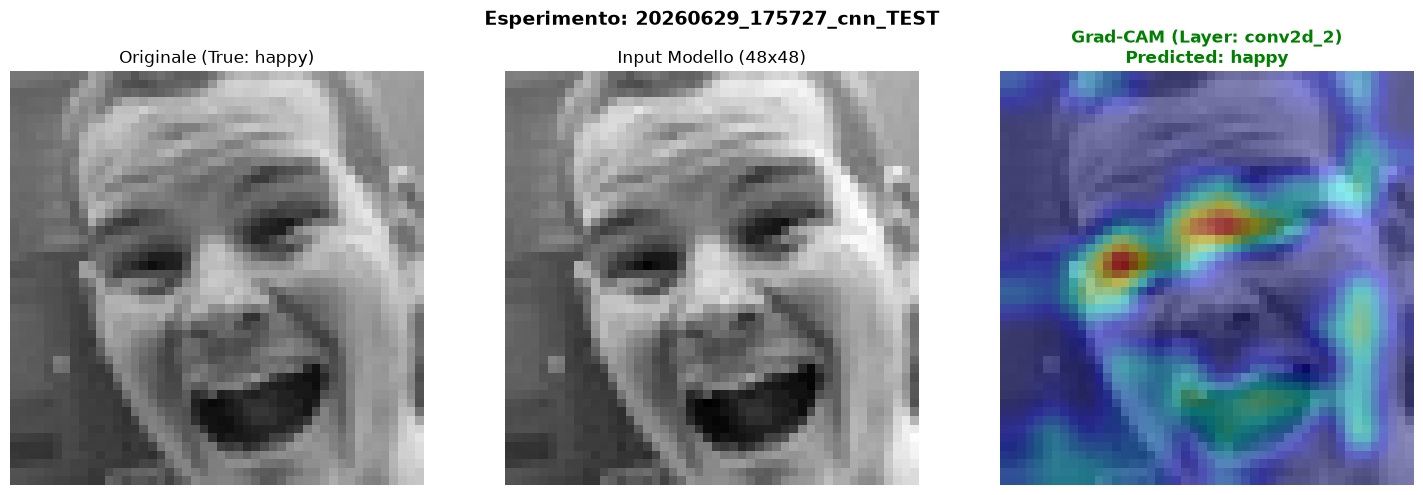


[ELABORAZIONE] Elaboro il modello: 20260629_185100_cnn_complex_v1
 -> Layer selezionato per Grad-CAM: 'conv2d_9' (Nidificato: False)


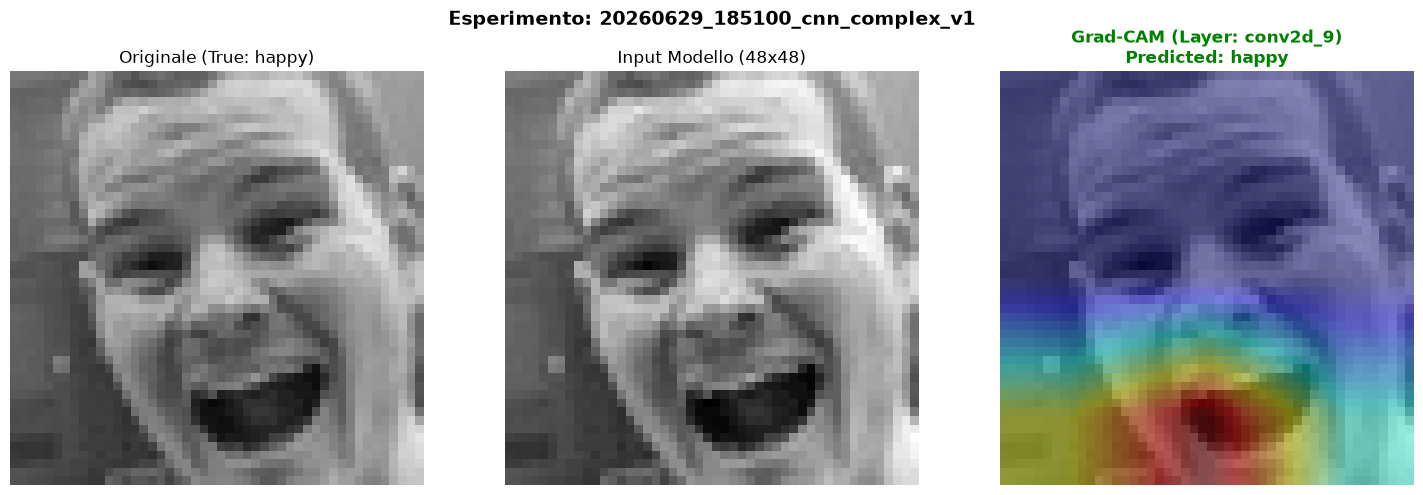


[COMPLETATO] Tutti i modelli sono stati elaborati e salvati in gradcam_results!


In [48]:
# --- 3. LOOP SU TUTTI I MODELLI IN EXPERIMENTS ---
for cartella_esperimento in os.listdir(PATH_EXPERIMENTS):
    path_modello_dir = os.path.join(PATH_EXPERIMENTS, cartella_esperimento)
    
    if not os.path.isdir(path_modello_dir):
        continue
        
    # Definiamo i nomi dei file che vogliamo cercare
    nomi_modelli_cercati = ["model.keras", "model_test.keras"] #Eliminare questo e il ciclo for nel caso si uniformino i nomi dei modelli salvati
    
    for nome_file_modello in nomi_modelli_cercati:
        path_model_keras = os.path.join(path_modello_dir, nome_file_modello)
    
        if os.path.exists(path_model_keras):
            print(f"\n[ELABORAZIONE] Elaboro il modello: {cartella_esperimento}")
            
            try:
                keras.backend.clear_session()
                model = keras.models.load_model(path_model_keras)
                
                # --- PREPARAZIONE CANALI INPUT E RIDIMENSIONAMENTO DINAMICO ---
                input_shape = model.input_shape  
                req_altezza = input_shape[1]
                req_larghezza = input_shape[2]
                req_canali = input_shape[3]

                # 1. Resize geometrico
                if req_altezza != 48 or req_larghezza != 48:
                    img_rescaled = cv2.resize(img_proc, (req_larghezza, req_altezza), interpolation=cv2.INTER_LINEAR)
                    img_proc_input_eval = img_rescaled.astype("float32") / 255.0
                    img_proc_input_eval = np.expand_dims(np.expand_dims(img_proc_input_eval, axis=-1), axis=0)
                else:
                    img_proc_input_eval = img_proc_input

                # 2. Controllo Canali (Es. Grayscale -> RGB per Transfer Learning)
                if req_canali == 3 and img_proc_input_eval.shape[-1] == 1:
                    current_input = np.repeat(img_proc_input_eval, 3, axis=-1)
                else:
                    current_input = img_proc_input_eval

                current_input_tensor = tf.convert_to_tensor(current_input, dtype=tf.float32)

                # Chiamata fittizia di inizializzazione nodi
                _ = model(current_input_tensor)
                
                # --- IDENTIFICAZIONE DEL LAYER TARGET E DELLA STRUTTURA ---
                target_layer_name = None
                is_nested_model = False
                nested_model_layer = None
                
                # Scansione dinamica per trovare l'ultimo layer convoluzionale o di attivazione utile
                for layer in reversed(model.layers):
                    if isinstance(layer, keras.models.Model) or hasattr(layer, 'layers'):
                        for sub_layer in reversed(layer.layers):
                            if "conv" in sub_layer.name or "relu" in sub_layer.name:
                                target_layer_name = sub_layer.name
                                is_nested_model = True
                                nested_model_layer = layer
                                break
                    elif "conv" in layer.name or "relu" in layer.name:
                        target_layer_name = layer.name
                    
                    if target_layer_name is not None:
                        break
                
                if target_layer_name is None:
                    print(f" -> Impossibile trovare un layer convoluzionale valido. Salto.")
                    continue
                    
                print(f" -> Layer selezionato per Grad-CAM: '{target_layer_name}' (Nidificato: {is_nested_model})")

                # --- APPLICAZIONE METODO FUSO ---
                cam, class_index = get_gradcam_heatmap(
                    current_input_tensor, model, target_layer_name, is_nested_model, nested_model_layer
                )
                
                # --- CREAZIONE OVERLAY VISIVO ---
                heatmap_resized = cv2.resize(cam, (larghezza_orig, altezza_orig))
                heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
                heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
                
                overlay = cv2.addWeighted(img_originale_rgb, 0.6, heatmap_color, 0.4, 0)
                classe_pred = CLASSI[class_index]
                
                # --- CREAZIONE DEL PLOT E VISUALIZZAZIONE ---
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                
                axes[0].imshow(img_originale_rgb)
                axes[0].set_title(f"Originale (True: {NOME_CLASSE})")
                axes[0].axis("off")
                
                img_proc_visualizza = cv2.resize(img_proc, (req_larghezza, req_altezza), interpolation=cv2.INTER_LINEAR)
                axes[1].imshow(img_proc_visualizza, cmap="gray")
                axes[1].set_title(f"Input Modello ({req_larghezza}x{req_altezza})")
                axes[1].axis("off")
                
                axes[2].imshow(overlay)
                title_color = "green" if NOME_CLASSE == classe_pred else "red"
                axes[2].set_title(f"Grad-CAM (Layer: {target_layer_name})\nPredicted: {classe_pred}", color=title_color, fontweight="bold")
                axes[2].axis("off")
                
                plt.suptitle(f"Esperimento: {cartella_esperimento}", fontsize=14, fontweight='bold')
                plt.tight_layout()
                
                # Salvataggio automatico facoltativo del plot combinato
                output_file_path = os.path.join(PATH_OUTPUT_PLOT, f"gradcam_{cartella_esperimento}.png")
                plt.savefig(output_file_path, bbox_inches='tight', dpi=150)
                
                plt.show()
                
            except Exception as e:
                print(f" -> Errore durante l'elaborazione di {cartella_esperimento}: {e}")
            
print("\n[COMPLETATO] Tutti i modelli sono stati elaborati e salvati in gradcam_results!")